In [2]:
import csv
def load_csv(filename):
    x_data = []
    y_data = []
    with open(filename, "r") as file:
        reader = csv.reader(file)
        for row in reader:
            x_data.append([float(row[0]), float(row[1])])
            y_data.append(float(row[2]))
    return x_data, y_data
x_data, y_data = load_csv("loan2.csv")


In [3]:
import math
def sigmoid(z):
    return 1 / (1 + math.exp(-z))
def function(w):
    w1 = w[0]
    w2 = w[1]
    w0 = w[2]
    total = 0.0
    n = len(x_data)
    for x, y in zip(x_data, y_data):
        z = w1 * x[0] + w2 * x[1] + w0
        total += y * z - math.log(1 + math.exp(z))
    return -total / n

In [4]:
def derivative(f, w):
    w1 = w[0]
    w2 = w[1]
    w0 = w[2]
    dL_dw1 = 0
    dL_dw2 = 0
    dL_dw0 = 0
    n = len(x_data)
    for xi, yi in zip(x_data, y_data):
        z = w1 * xi[0] + w2 * xi[1] + w0
        s = sigmoid(-z)  
        dL_dw0 += -yi + (1 - s)
        dL_dw1 += -yi * xi[0] + xi[0] * (1 - s)
        dL_dw2 += -yi * xi[1] + xi[1] * (1 - s)
    dL_dw0 /= n
    dL_dw1 /= n
    dL_dw2 /= n
    return [dL_dw1, dL_dw2, dL_dw0]

In [5]:
def gradient_descent(f, x0, l, min=1e-6):
    x = x0
    step = 0
    fx_val_old = 0
    print(f"Step | x | f(x) | grad")
    while True:
        fx_val = f(x)
        grad = derivative(f, x)
        print(f"{step} | {x} | {fx_val} | {grad}")
        if step > 0 and abs(fx_val_old - fx_val) < min:
            break
        fx_val_old = fx_val
        x[0] = x[0] - l * grad[0]
        x[1] = x[1] - l * grad[1]
        x[2] = x[2] - l * grad[2]
        step += 1
    return x

In [10]:
result = gradient_descent(f=function, x0=[1,1,1], l=0.1)
print(f"\nResult: w1 = {result[0]}, w2 = {result[1]}, w0 = {result[2]}")

Step | x | f(x) | grad
0 | [1, 1, 1] | 4.216215162126339 | [0.26797436616592074, 3.418905316048974, 0.5258903656510857]
1 | [0.9732025633834079, 0.6581094683951025, 0.9474109634348914] | 3.014112905410574 | [0.2659365880387, 3.4052969756982403, 0.5235030091389853]
2 | [0.946608904579538, 0.3175797708252785, 0.8950606625209929] | 1.8342656450449117 | [0.2526325921806426, 3.2806185727236596, 0.5040395162663242]
3 | [0.9213456453614737, -0.01048208644708748, 0.8446567108943606] | 0.846752835857448 | [0.16191263173922418, 2.249738266176198, 0.3579886193512576]
4 | [0.9051543821875513, -0.2354559130647073, 0.8088578489592348] | 0.5479371555715093 | [-0.048859273132441296, 0.2041682671182566, 0.07574165172023593]
5 | [0.9100403095007954, -0.25587273977653296, 0.8012836837872113] | 0.5450047817949955 | [-0.07255116338231153, 0.009043358661323839, 0.048283396892967026]
6 | [0.9172954258390266, -0.25677707564266533, 0.7964553440979145] | 0.5442425080789494 | [-0.07231896085502545, 0.00293177854

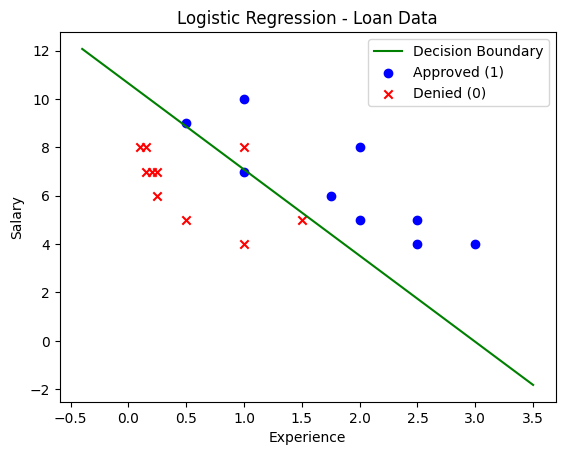

In [11]:
import matplotlib.pyplot as plt
import numpy as np
for xi, yi in zip(x_data, y_data):
    color = "blue" if yi == 1 else "red"
    marker = "o" if yi == 1 else "x"
    plt.scatter(xi[0], xi[1], color=color, marker=marker)
x1_vals = np.linspace(min(x[0] for x in x_data) - 0.5, max(x[0] for x in x_data) + 0.5, 100)
x2_vals = -(result[0] * x1_vals + result[2]) / result[1]
plt.plot(x1_vals, x2_vals, "g-", label="Decision Boundary")
plt.scatter([], [], color="blue", marker="o", label="Approved (1)")
plt.scatter([], [], color="red", marker="x", label="Denied (0)")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Logistic Regression - Loan Data")
plt.legend()
plt.show()
